# Pipeline de Treinamento — Previsão de `geek_rating` (BoardGameGeek)

Este notebook treina e compara 4 modelos para prever o **geek_rating** (Bayesian rating do BGG) a partir da base já normalizada em `normalization.ipynb`:

| Modelo | Tipo | Target usado |
|---|---|---|
| Regressão Linear | Regressão | `geek_rating` contínuo |
| Random Forest Regressor | Regressão | `geek_rating` contínuo |
| Gradient Boosting Regressor | Regressão | `geek_rating` contínuo |
| Regressão Logística | Classificação (10 classes) | `geek_rating` discretizado em 10 faixas |

**Por que a Regressão Logística é tratada separadamente?**
Regressão logística é, por natureza, um modelo de **classificação**, não de regressão contínua. Para usá-la na previsão de `geek_rating`, discretizamos o valor contínuo em **10 faixas (bins) de largura igual**, cobrindo o intervalo observado de `geek_rating` no conjunto de treino — ou seja, transformamos o problema em uma classificação multiclasse com classes de 0 a 9 (decis de amplitude, não de frequência).

> ⚠️ Os limites das faixas (bins) são calculados **apenas com os dados de treino** e depois aplicados ao teste, para evitar vazamento de informação (data leakage).

Todos os 4 modelos têm seus hiperparâmetros otimizados via `GridSearchCV`.

## 1. Imports

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42


## 2. Carregamento dos dados

Carregamos `bgg_normalized.csv`, gerado pelo notebook `normalization.ipynb`. A base já está limpa, sem valores nulos, com variáveis categóricas codificadas (one-hot para categorias/mecânicas), publisher e descrição vetorizados, e features numéricas padronizadas com `RobustScaler`. O `geek_rating` (nosso target) permanece na escala original.

In [2]:
df = pd.read_csv("bgg_normalized.csv")

print(f"Shape: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print(f"Valores nulos totais: {df.isna().sum().sum()}")
df.head()


Shape: 25,367 linhas x 205 colunas
Valores nulos totais: 0


,geek_rating,min_suggested_age,complexity,min_players,max_players,min_time,max_time,has_description,year_is_missing,min_suggested_age_is_missing,min_players_is_missing,max_players_is_missing,min_time_is_missing,max_time_is_missing,cat_Abstract Strategy,cat_Action,cat_Adventure,cat_Ancient,cat_Animals,cat_Bluffing,cat_Card Game,cat_Children's Game,cat_City Building,cat_Civilization,cat_Deduction,...,desc_topic_51,desc_topic_52,desc_topic_53,desc_topic_54,desc_topic_55,desc_topic_56,desc_topic_57,desc_topic_58,desc_topic_59,desc_topic_60,desc_topic_61,desc_topic_62,desc_topic_63,desc_topic_64,desc_topic_65,desc_topic_66,desc_topic_67,desc_topic_68,desc_topic_69,desc_topic_70,desc_topic_71,desc_topic_72,desc_topic_73,desc_topic_74,desc_topic_75
0,8.394,1.00,1.689076,0.0,0.0,0.75,1.25,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,-2.024583,0.666425,0.516949,1.479594,-0.500602,0.143517,0.166705,2.834937,-1.563149,-1.260927,1.322877,0.632911,-0.526987,1.988088,-3.252902,2.070221,-0.719700,1.816869,1.970418,0.597998,4.908805,-1.804203,-0.435839,-0.606994,0.277209
1,8.354,1.00,1.638655,-1.0,0.0,1.50,1.75,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,...,0.642002,1.764341,0.005770,-0.270380,1.532676,1.374852,-1.067618,-2.420568,1.545560,1.564916,-1.150506,-1.869465,-1.414546,2.434262,-0.639044,1.027015,0.682169,-1.419891,1.755171,0.483439,0.624969,-0.522448,0.947509,1.985153,-0.916087
2,8.345,0.75,0.823529,0.0,0.0,0.75,0.25,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,-1.065846,-1.326894,-2.245832,-0.983458,2.483927,4.116185,1.789552,-0.556545,-3.562150,1.565705,2.046477,2.223258,2.416424,-0.933164,-0.047338,-1.010764,-4.145801,2.272989,-3.119154,-0.402430,1.052620,-1.625310,0.887101,-1.587028,1.599852
3,8.296,1.00,1.739496,-1.0,0.0,0.75,1.25,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,...,-2.120657,0.024832,1.132633,7.897547,-11.625171,4.452114,-9.990726,0.854617,-3.129307,1.360337,4.504751,-4.391742,-0.849080,8.957303,0.217778,-4.973735,0.009902,3.017265,1.637871,3.547199,4.013492,-3.046367,4.392534,1.078074,-0.107413
4,8.244,0.75,1.403361,-1.0,1.0,0.75,1.25,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,-1.108061,3.864119,0.046615,5.230218,-0.737826,1.521040,-2.430875,-1.289657,-4.263710,0.688793,4.343143,2.930437,-5.947502,-1.635460,0.560339,-2.177439,-2.131443,0.707284,5.436875,0.033634,11.832689,-3.155299,9.558943,6.702026,6.496080


In [3]:
df["geek_rating"].describe()


count    25367.000000
mean         5.693836
std          0.371549
min          5.268000
25%          5.507000
50%          5.529000
75%          5.699000
max          8.483000
Name: geek_rating, dtype: float64

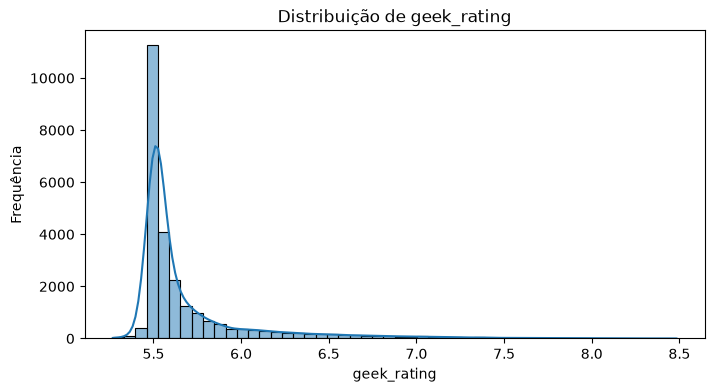

In [4]:
plt.figure(figsize=(8, 4))
sns.histplot(df["geek_rating"], bins=50, kde=True)
plt.title("Distribuição de geek_rating")
plt.xlabel("geek_rating")
plt.ylabel("Frequência")
plt.show()


**Observação importante sobre a distribuição:** o `geek_rating` é fortemente assimétrico à direita. A maioria dos jogos se concentra perto do "piso" do Bayesian average do BGG (em torno de 5.5), e poucos jogos atingem ratings altos (>7.5). Isso afeta diretamente a versão de classificação (Regressão Logística): as faixas mais altas terão poucas amostras, o que é esperado e será discutido nos resultados.

## 3. Separação de features e targets

- `X`: todas as colunas exceto `geek_rating`.
- `y_reg`: o `geek_rating` contínuo (usado em Regressão Linear, Random Forest e Gradient Boosting).
- O target de classificação (`y_clf`) será derivado de `y_reg` *depois* do split treino/teste, para não vazar informação do teste na definição das faixas.

In [5]:
X = df.drop(columns=["geek_rating"])
y_reg = df["geek_rating"]

print(f"X: {X.shape}")
print(f"y_reg: {y_reg.shape}")


X: (25367, 204)
y_reg: (25367,)


## 4. Split treino/teste

Usamos `train_test_split` com 80% treino / 20% teste. Como as features já vêm padronizadas (RobustScaler) e codificadas do notebook de normalização, não há necessidade de pré-processamento adicional aqui.

In [6]:
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Treino: {X_train.shape[0]:,} amostras")
print(f"Teste:  {X_test.shape[0]:,} amostras")


Treino: 20,293 amostras
Teste:  5,074 amostras


## 5. Discretização do target para a Regressão Logística

Criamos 10 faixas de **largura igual** (bins lineares, `np.linspace`) cobrindo o intervalo `[min, max]` de `geek_rating` observado **no treino**. As extremidades dos bins são abertas para `-inf`/`+inf`, garantindo que qualquer valor do teste (mesmo fora do range do treino) seja classificado em alguma faixa, sem gerar `NaN`.

As classes resultantes vão de `0` (faixa mais baixa) a `9` (faixa mais alta).

In [7]:
N_BINS = 10

bin_edges = np.linspace(y_train_reg.min(), y_train_reg.max(), N_BINS + 1)

# Rótulos legíveis para cada faixa (antes de abrir as extremidades)
bin_labels_desc = [f"{bin_edges[i]:.3f} – {bin_edges[i+1]:.3f}" for i in range(N_BINS)]

# Abre as extremidades para +-inf, para cobrir qualquer valor do teste
bin_edges_open = bin_edges.copy()
bin_edges_open[0] = -np.inf
bin_edges_open[-1] = np.inf

y_train_clf = pd.cut(y_train_reg, bins=bin_edges_open, labels=False, include_lowest=True)
y_test_clf = pd.cut(y_test_reg, bins=bin_edges_open, labels=False, include_lowest=True)

print("Faixas de geek_rating (definidas a partir do treino):")
for i, lbl in enumerate(bin_labels_desc):
    print(f"  Classe {i}: {lbl}")


Faixas de geek_rating (definidas a partir do treino):
  Classe 0: 5.268 – 5.590
  Classe 1: 5.590 – 5.911
  Classe 2: 5.911 – 6.232
  Classe 3: 6.232 – 6.554
  Classe 4: 6.554 – 6.876
  Classe 5: 6.876 – 7.197
  Classe 6: 7.197 – 7.519
  Classe 7: 7.519 – 7.840
  Classe 8: 7.840 – 8.162
  Classe 9: 8.162 – 8.483


             treino  teste
geek_rating               
0             12770   3123
1              4540   1186
2              1240    363
3               768    173
4               445    101
5               277     71
6               142     37
7                77     15
8                23      5
9                11      0


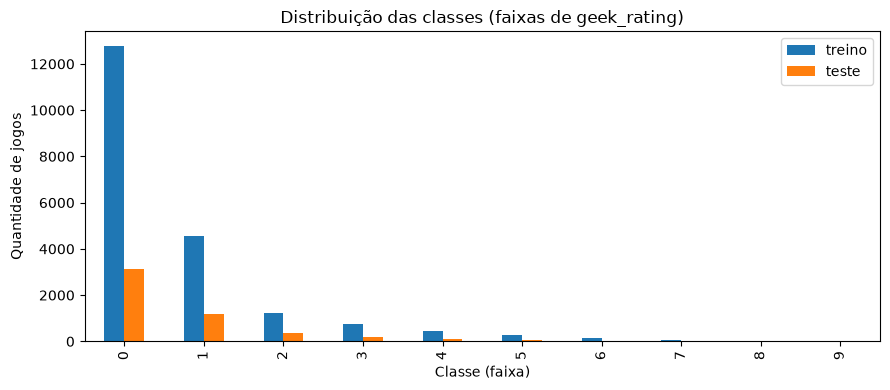

In [8]:
dist_treino = y_train_clf.value_counts().sort_index()
dist_teste = y_test_clf.value_counts().sort_index()

dist_df = pd.DataFrame({"treino": dist_treino, "teste": dist_teste}).fillna(0).astype(int)
print(dist_df)

plt.figure(figsize=(9, 4))
dist_df.plot(kind="bar", ax=plt.gca())
plt.title("Distribuição das classes (faixas de geek_rating)")
plt.xlabel("Classe (faixa)")
plt.ylabel("Quantidade de jogos")
plt.tight_layout()
plt.show()


⚠️ **Forte desbalanceamento de classes.** As classes 0 e 1 concentram a grande maioria dos jogos; as classes mais altas (7, 8, 9) têm poucas dezenas de exemplos. Por isso:

- Usamos `class_weight="balanced"` na Regressão Logística, para compensar o desbalanceamento durante o treino.
- Avaliamos com **F1-score ponderado (weighted)** como métrica principal do GridSearchCV (mais robusta a desbalanceamento que a acurácia simples), além de reportar accuracy e o relatório completo por classe.

## 6. Função auxiliar de avaliação (regressão)

Função utilitária para reportar RMSE, MAE e R² de forma consistente entre os 3 modelos de regressão.

In [9]:
def avaliar_regressao(nome_modelo, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"--- {nome_modelo} ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")

    return {"modelo": nome_modelo, "RMSE": rmse, "MAE": mae, "R2": r2}


## 7. Modelo 1 — Regressão Linear

Modelo baseline. O grid de hiperparâmetros é pequeno (a Regressão Linear tem poucos parâmetros relevantes), mas ainda assim passamos pelo `GridSearchCV` para manter a metodologia consistente entre os modelos.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
import time

# 1. Cria o Pipeline
pipeline_lr = Pipeline([
    ('scaler', RobustScaler()), 
    ('modelo', LinearRegression())
])

# 2. Adiciona o prefixo 'modelo__'
param_grid_lr = {
    "modelo__fit_intercept": [True, False],
    "modelo__positive": [False, True]
}

t0 = time.time()
grid_linear = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid_lr,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

# Lembre-se: X_train deve ser o dado antes do RobustScaler
grid_linear.fit(X_train, y_train_reg)

print(f"Tempo de treinamento: {time.time() - t0:.1f}s")
print(f"Melhores hiperparâmetros: {grid_linear.best_params_}")
print(f"Melhor R² (validação cruzada): {grid_linear.best_score_:.4f}")

Tempo de treinamento: 17.6s
Melhores hiperparâmetros: {'fit_intercept': True, 'positive': True}
Melhor R² (validação cruzada): 0.3084


In [11]:
modelo_linear = grid_linear.best_estimator_
resultado_linear = avaliar_regressao("Regressão Linear", modelo_linear, X_test, y_test_reg)


--- Regressão Linear ---
RMSE: 0.3116
MAE:  0.1947
R²:   0.2607


## 8. Modelo 2 — Random Forest Regressor

Random Forest costuma capturar bem relações não-lineares entre as features (ex: número de votos, complexidade, categorias) e o `geek_rating`.

> 💡 **Nota de performance:** o grid abaixo foi dimensionado para terminar em alguns minutos em uma máquina comum. Se você tiver mais núcleos de CPU disponíveis, pode expandir as listas de `n_estimators`/`max_depth`/`min_samples_leaf` para uma busca mais ampla — o `n_jobs=-1` já paraleliza entre as combinações do grid. Tempo estimado com o grid abaixo: ~10-30 min em CPU com poucos núcleos; bem mais rápido com 4+ núcleos.

In [ ]:
import time
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# 1. Criamos o Pipeline com o Scaler e o Random Forest
pipeline_rf = Pipeline([
    ('scaler', RobustScaler()), 
    ('modelo', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1))
])

# 2. Atualizamos o grid adicionando 'modelo__' antes de cada hiperparâmetro
param_grid_rf = {
    "modelo__n_estimators": [100, 200],
    "modelo__max_depth": [8, 12, None],
    "modelo__min_samples_leaf": [1, 4],
}

t0 = time.time()

# 3. O GridSearchCV agora otimiza o pipeline inteiro, garantindo isolamento em cada fold
grid_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    cv=3,
    scoring="r2",
    n_jobs=-1,
)

# X_train deve ser o dado CRU (antes da normalização)
grid_rf.fit(X_train, y_train_reg)

print(f"Tempo de treinamento: {time.time() - t0:.1f}s")
print(f"Melhores hiperparâmetros: {grid_rf.best_params_}")
print(f"Melhor R² (validação cruzada): {grid_rf.best_score_:.4f}")


Tempo de treinamento: 957.2s
Melhores hiperparâmetros: {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 200}
Melhor R² (validação cruzada): 0.3781


In [13]:
modelo_rf = grid_rf.best_estimator_
resultado_rf = avaliar_regressao("Random Forest", modelo_rf, X_test, y_test_reg)


--- Random Forest ---
RMSE: 0.2953
MAE:  0.1692
R²:   0.3363


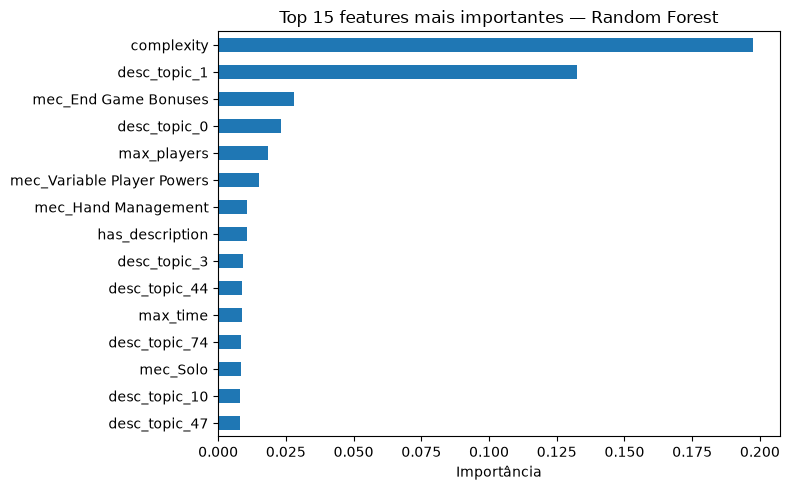

In [14]:
# Importância das features (Random Forest)
importancias = pd.Series(modelo_rf.feature_importances_, index=X_train.columns)
top15 = importancias.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
top15.sort_values().plot(kind="barh")
plt.title("Top 15 features mais importantes — Random Forest")
plt.xlabel("Importância")
plt.tight_layout()
plt.show()


## 9. Modelo 3 — Gradient Boosting Regressor

Gradient Boosting ajusta árvores sequencialmente, cada uma corrigindo os erros da anterior. Tende a ter desempenho competitivo, ao custo de mais tempo de treino.

> 💡 Mesma observação de performance do Random Forest: o grid foi dimensionado para tempo razoável (~5-15 min em CPU com poucos núcleos). Aumente se tiver capacidade computacional disponível.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# 1. Cria o Pipeline
pipeline_gb = Pipeline([
    ('scaler', RobustScaler()), 
    ('modelo', GradientBoostingRegressor(random_state=RANDOM_STATE))
])

# 2. Adiciona o prefixo 'modelo__'
param_grid_gb = {
    "modelo__n_estimators": [100, 200],
    "modelo__learning_rate": [0.05, 0.1, 0.2],
    "modelo__max_depth": [3, 4, 5]
}

t0 = time.time()
grid_gb = GridSearchCV(
    estimator=pipeline_gb,
    param_grid=param_grid_gb,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_gb.fit(X_train, y_train_reg)

print(f"Tempo de treinamento: {time.time() - t0:.1f}s")
print(f"Melhores hiperparâmetros: {grid_gb.best_params_}")
print(f"Melhor R² (validação cruzada): {grid_gb.best_score_:.4f}")

Tempo de treinamento: 246.6s
Melhores hiperparâmetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Melhor R² (validação cruzada): 0.3756


In [16]:
modelo_gb = grid_gb.best_estimator_
resultado_gb = avaliar_regressao("Gradient Boosting", modelo_gb, X_test, y_test_reg)


--- Gradient Boosting ---
RMSE: 0.2972
MAE:  0.1713
R²:   0.3276


## 10. Modelo 4 — Regressão Logística (classificação em 10 faixas)

Usamos `y_train_clf` / `y_test_clf` (as 10 faixas definidas na seção 5). `class_weight="balanced"` ajusta os pesos das classes para compensar o desbalanceamento.

> Nota: com 10 classes e forte desbalanceamento, é normal ver um aviso de convergência do solver `lbfgs` mesmo com `max_iter` razoavelmente alto — isso não impede o uso do modelo, apenas indica que o otimizador não atingiu o ponto de mínimo absoluto. Testes preliminares mostraram que aumentar `max_iter` muito além de 1000 não melhora o F1 no teste de forma perceptível, então mantivemos um valor que equilibra qualidade e tempo de treino.

In [17]:
import time
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# 1. Criamos o Pipeline: o dado passa primeiro pelo Scaler e depois vai para o Modelo
pipeline_logistico = Pipeline([
    ('scaler', RobustScaler()), # A normalização acontece aqui dentro, a salvo de vazamentos
    ('modelo', LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ))
])

# 2. Ajustamos o dicionário de hiperparâmetros (adicionamos o prefixo 'modelo__' 
# para o GridSearch saber que esses parâmetros pertencem à regressão e não ao scaler)
param_grid_logistic = {
    "modelo__C": [0.01, 0.1, 1, 10],
    "modelo__solver": ["lbfgs"],
}

t0 = time.time()

# 3. O GridSearchCV agora recebe o pipeline inteiro como estimador
grid_logistic = GridSearchCV(
    estimator=pipeline_logistico,
    param_grid=param_grid_logistic,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
)

# O fit permanece igual, mas agora X_train deve ser o seu dado CRU (antes do RobustScaler)
grid_logistic.fit(X_train, y_train_clf)

print(f"Tempo de treinamento: {time.time() - t0:.1f}s")
print(f"Melhores hiperparâmetros: {grid_logistic.best_params_}")
print(f"Melhor F1 ponderado (validação cruzada): {grid_logistic.best_score_:.4f}")

/home/caik/trabalho_machine_learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/caik/trabalho_machine_learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://sci

Tempo de treinamento: 189.5s
Melhores hiperparâmetros: {'modelo__C': 0.1, 'modelo__solver': 'lbfgs'}
Melhor F1 ponderado (validação cruzada): 0.5476


In [18]:
modelo_logistic = grid_logistic.best_estimator_
y_pred_clf = modelo_logistic.predict(X_test)

acc = accuracy_score(y_test_clf, y_pred_clf)
f1_weighted = f1_score(y_test_clf, y_pred_clf, average="weighted")
precision_weighted = precision_score(y_test_clf, y_pred_clf, average="weighted", zero_division=0)
recall_weighted = recall_score(y_test_clf, y_pred_clf, average="weighted", zero_division=0)

print("--- Regressão Logística (10 classes) ---")
print(f"Accuracy:           {acc:.4f}")
print(f"F1 (weighted):       {f1_weighted:.4f}")
print(f"Precision (weighted): {precision_weighted:.4f}")
print(f"Recall (weighted):    {recall_weighted:.4f}")
print()
print(classification_report(y_test_clf, y_pred_clf, zero_division=0))


--- Regressão Logística (10 classes) ---
Accuracy:           0.4781
F1 (weighted):       0.5366
Precision (weighted): 0.6235
Recall (weighted):    0.4781

              precision    recall  f1-score   support

           0       0.86      0.65      0.74      3123
           1       0.35      0.23      0.28      1186
           2       0.12      0.13      0.12       363
           3       0.08      0.23      0.12       173
           4       0.04      0.12      0.06       101
           5       0.03      0.11      0.05        71
           6       0.02      0.16      0.04        37
           7       0.01      0.07      0.01        15
           8       0.02      0.20      0.04         5
           9       0.00      0.00      0.00         0

    accuracy                           0.48      5074
   macro avg       0.15      0.19      0.15      5074
weighted avg       0.62      0.48      0.54      5074



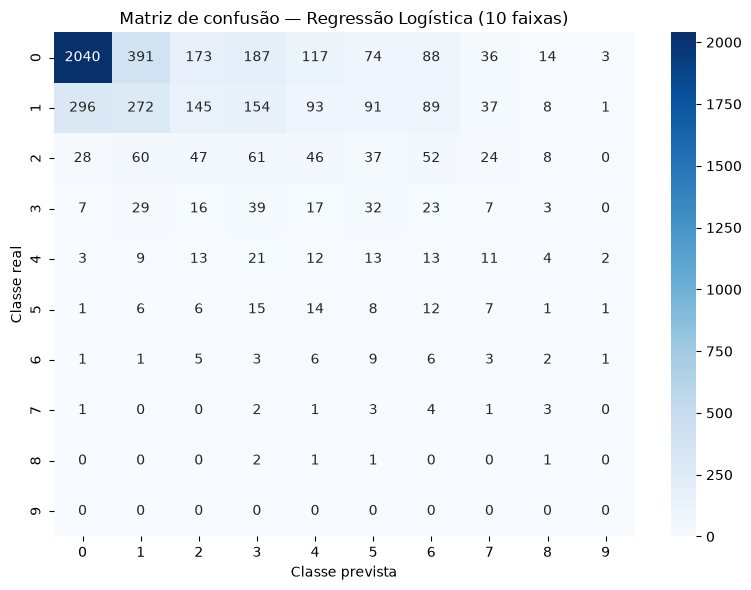

In [19]:
cm = confusion_matrix(y_test_clf, y_pred_clf, labels=range(N_BINS))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(N_BINS), yticklabels=range(N_BINS))
plt.title("Matriz de confusão — Regressão Logística (10 faixas)")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.tight_layout()
plt.show()


In [20]:
resultado_logistic = {
    "modelo": "Regressão Logística (10 classes)",
    "Accuracy": acc,
    "F1_weighted": f1_weighted,
    "Precision_weighted": precision_weighted,
    "Recall_weighted": recall_weighted,
}


## 11. Comparação final dos modelos

Como a Regressão Logística resolve um problema diferente (classificação em 10 faixas, e não regressão contínua), reportamos suas métricas separadamente das métricas de regressão (RMSE, MAE, R²) dos outros 3 modelos.

In [21]:
tabela_regressao = pd.DataFrame([resultado_linear, resultado_rf, resultado_gb]).set_index("modelo")
tabela_regressao = tabela_regressao.sort_values("R2", ascending=False)
print("Comparação — Modelos de Regressão (target contínuo)")
tabela_regressao


Comparação — Modelos de Regressão (target contínuo)


,RMSE,MAE,R2
modelo,,,
Random Forest,0.295286,0.169175,0.336257
Gradient Boosting,0.297216,0.171338,0.327553
Regressão Linear,0.311643,0.194652,0.260686


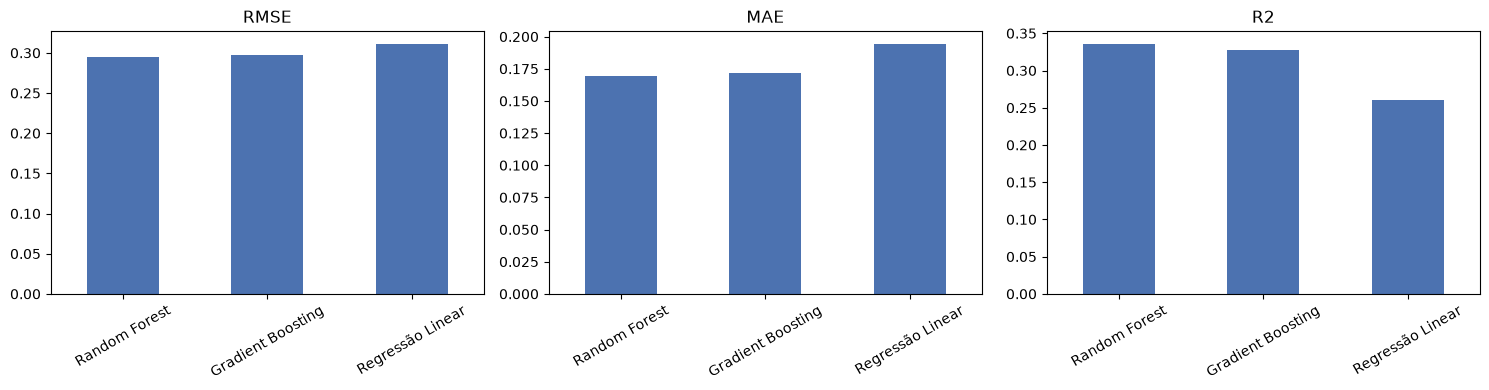

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metrica in zip(axes, ["RMSE", "MAE", "R2"]):
    tabela_regressao[metrica].plot(kind="bar", ax=ax, color="#4C72B0")
    ax.set_title(metrica)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


In [23]:
tabela_classificacao = pd.DataFrame([resultado_logistic]).set_index("modelo")
print("Resultado — Regressão Logística (target discretizado em 10 faixas)")
tabela_classificacao


Resultado — Regressão Logística (target discretizado em 10 faixas)


,Accuracy,F1_weighted,Precision_weighted,Recall_weighted
modelo,,,,
Regressão Logística (10 classes),0.478124,0.536644,0.623456,0.478124


## 12. Resumo dos melhores hiperparâmetros encontrados (GridSearchCV)

In [24]:
resumo_hiperparametros = pd.DataFrame([
    {"modelo": "Regressão Linear", "melhores_hiperparametros": grid_linear.best_params_, "score_cv": grid_linear.best_score_, "metrica_cv": "R2"},
    {"modelo": "Random Forest", "melhores_hiperparametros": grid_rf.best_params_, "score_cv": grid_rf.best_score_, "metrica_cv": "R2"},
    {"modelo": "Gradient Boosting", "melhores_hiperparametros": grid_gb.best_params_, "score_cv": grid_gb.best_score_, "metrica_cv": "R2"},
    {"modelo": "Regressão Logística", "melhores_hiperparametros": grid_logistic.best_params_, "score_cv": grid_logistic.best_score_, "metrica_cv": "F1_weighted"},
])
resumo_hiperparametros


,modelo,melhores_hiperparametros,score_cv,metrica_cv
0,Regressão Linear,"{'fit_intercept': True, 'positive': True}",0.308396,R2
1,Random Forest,"{'max_depth': None, 'min_samples_leaf': 4, 'n_...",0.378145,R2
2,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.375607,R2
3,Regressão Logística,"{'modelo__C': 0.1, 'modelo__solver': 'lbfgs'}",0.547560,F1_weighted


## 13. Conclusões

- Os 3 modelos de regressão (Linear, Random Forest, Gradient Boosting) são diretamente comparáveis por RMSE, MAE e R², pois preveem o `geek_rating` na escala original.
- A Regressão Logística resolve uma tarefa diferente (classificar em qual de 10 faixas o jogo cai) e é avaliada por métricas de classificação (accuracy, F1, precision, recall).
- O forte desbalanceamento de classes em `geek_rating` (poucos jogos com rating muito alto) afeta principalmente a Regressão Logística nas faixas superiores — isso é esperado e reflete a própria distribuição do Bayesian rating do BGG, não um erro no pipeline.
- O `GridSearchCV` identificou os melhores hiperparâmetros para cada modelo dentro dos grids definidos. Se desejar uma busca mais ampla (mais valores por hiperparâmetro), os grids podem ser expandidos — o principal custo adicional cairá sobre Random Forest e Gradient Boosting, que são os mais caros computacionalmente.